# The Grossman--Larson (GL) Hopf Algebra

This notebook demonstrates the **Grossman--Larson Hopf algebra** as implemented in the `kauri` package.

The GL Hopf algebra was introduced by Grossman and Larson (1989) and is defined on the vector space of
non-planar (unordered) rooted trees. Unlike the Butcher--Connes--Kreimer (BCK) Hopf algebra, whose product
is forest concatenation, the GL product is the **grafting product**. The unit is the single-vertex tree
$\bullet$ (not the empty forest).

**Key references:**

- R. Grossman and R. G. Larson, *Hopf-algebraic structure of families of trees*,
  J. Algebra **126** (1989), 184--210.
- M. E. Hoffman, *(Non)commutative Hopf algebras of trees and (quasi)symmetric functions*,
  arXiv: [0710.3739](https://arxiv.org/abs/0710.3739), 2007.

In [1]:
import kauri as kr
import kauri.gl as gl

In [2]:
# Named trees for convenience
bullet = kr.Tree([])           # single-vertex tree
chain2 = kr.Tree([[]])         # 2-node chain
cherry = kr.Tree([[], []])     # cherry (two children)
chain3 = kr.Tree([[[]]])       # 3-node chain
trident = kr.Tree([[], [], []])  # 3-leaf star

## 1. The grafting product

For trees $s$ and $t = B_+(t_1, \ldots, t_k)$, the GL product is

$$
s \cdot_{GL} t \;=\; \sum_{f \colon \{1,\ldots,k\} \to V(s)}
  \mathrm{graft}(s,\, t_1,\ldots,t_k,\, f),
$$

where the sum runs over all assignments of the children $t_1, \ldots, t_k$ of $t$
to vertices of $s$, and each $t_i$ is grafted as a new child of vertex $f(i)$.

In Hoffman (2007, arXiv: [0710.3739](https://arxiv.org/abs/0710.3739), lines 421--450),
the product is written $s \circ t$, with the same convention:
the children of $t$ are distributed among the vertices of $s$.

In `kauri`, `gl.product(s, t)` computes $s \cdot_{GL} t$.

### The bullet is the unit

Since $\bullet = B_+()$ has no children, $s \cdot_{GL} \bullet = s$ for all $s$.
Similarly, $\bullet \cdot_{GL} t = t$ because $\bullet$ has only one vertex.

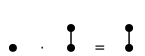

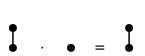

In [3]:
kr.display(bullet, "·", chain2, "=", gl.product(bullet, chain2))
kr.display(chain2, "·", bullet, "=", gl.product(chain2, bullet))

$B_+(\bullet)$ has one child ($\bullet$). Grafting that child onto
each of the 2 vertices of $s = B_+(\bullet)$ gives the cherry (graft at root) and the
3-node chain (graft at leaf).

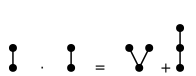

In [4]:
kr.display(chain2, "·", chain2, "=", gl.product(chain2, chain2))

### Noncommutativity of the GL product

The grafting product is **not commutative**. Following Hoffman (2007),
we compute the two products below and observe that they differ.

The difference arises because when both children of the cherry are grafted onto
the leaf of $B_+(\bullet)$, a term $B_+(\text{cherry})$ appears that has no
counterpart in the reversed product.

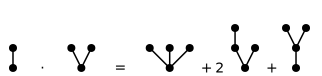

In [5]:
# Children of cherry grafted onto vertices of chain2
kr.display(chain2, "·", cherry, "=", gl.product(chain2, cherry))

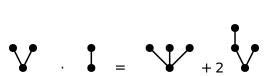

In [6]:
# Child of chain2 grafted onto vertices of cherry
kr.display(cherry, "·", chain2, "=", gl.product(cherry, chain2))

In [7]:
# The two products are not equal
print(gl.product(chain2, cherry) == gl.product(cherry, chain2))

False


## 2. Coproduct

The GL coproduct is **cocommutative** and is defined by splitting the children of the root
into all possible subsets. For $t = B_+(t_1, \ldots, t_k)$:

$$
\Delta_{GL}(t) \;=\; \sum_{S \subseteq \{1,\ldots,k\}}
  B_+(t_i : i \in S) \;\otimes\; B_+(t_j : j \notin S)
$$

This gives $2^k$ terms (before simplification). Note that
$\varepsilon_{GL}(\bullet) = 1$ and $\varepsilon_{GL}(t) = 0$ for $|t| > 1$.

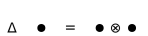

In [8]:
kr.display("Δ", bullet, "=", gl.coproduct(bullet))

### Chain trees are primitive

Any chain tree (a tree where every node has at most one child) has exactly one child
at the root, so $k=1$ and the coproduct has only two terms. Hence chain trees are
**primitive** elements of the GL Hopf algebra.

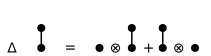

In [9]:
kr.display("Δ", chain2, "=", gl.coproduct(chain2))

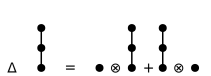

In [10]:
# chain3 is also primitive
kr.display("Δ", chain3, "=", gl.coproduct(chain3))

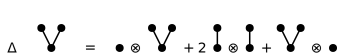

In [11]:
kr.display("Δ", cherry, "=", gl.coproduct(cherry))

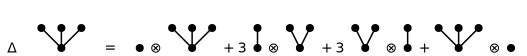

In [12]:
kr.display("Δ", trident, "=", gl.coproduct(trident))

## 3. Antipode

The GL antipode $S_{GL}$ is computed recursively:

- $S_{GL}(\bullet) = \bullet$
- For $|t| > 1$: $\;S_{GL}(t) = -t - \displaystyle\sum_{\substack{S \subset \{1,\ldots,k\} \\ S \neq \emptyset,\, S \neq \{1,\ldots,k\}}} S_{GL}\bigl(B_+(t_i : i \in S)\bigr) \cdot_{GL} B_+(t_j : j \notin S)$

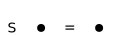

In [13]:
kr.display("S", bullet, "=", gl.antipode(bullet))

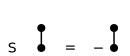

In [14]:
# Chain trees are primitive, so S = -id on them
kr.display("S", chain2, "=", gl.antipode(chain2))

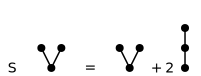

In [15]:
kr.display("S", cherry, "=", gl.antipode(cherry))

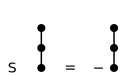

In [16]:
# S(chain3) = -chain3   (primitive => S = -id)
kr.display("S", chain3, "=", gl.antipode(chain3))

## 4. Hopf algebra axioms

### Counit

$\varepsilon_{GL}(\bullet) = 1$ and $\varepsilon_{GL}(t) = 0$ for $|t| > 1$.

In [17]:
print(gl.counit(bullet))   # 1
print(gl.counit(chain2))   # 0
print(gl.counit(cherry))   # 0

1
0
0


### Antipode property: $\mu_{GL} \circ (S_{GL} \otimes \mathrm{id}) \circ \Delta_{GL} = \eta \circ \varepsilon_{GL}$

This is verified for all trees up to order 5. For the bullet, $\eta(\varepsilon(\bullet)) = \bullet$,
and the convolution product `gl.map_product(gl.antipode, kr.ident)` returns a scalar (since the
GL product with $\bullet$ identifies $1 \cdot \bullet$ with $1$). We therefore compare against
`gl.counit(t)` for $|t| > 1$.

In [18]:
result = True
for t in kr.trees_up_to_order(5):
    if t.list_repr is None:
        continue
    lhs = gl.map_product(gl.antipode, kr.ident)(t)
    rhs = gl.counit(t)
    # For the bullet, lhs is a ForestSum "1 * bullet" which equals the counit value
    if t.nodes() == 1:
        continue
    if lhs != rhs:
        result = False
        break
print(result)

True


### Involutivity: $S_{GL}^2 = \mathrm{id}$

Since the GL Hopf algebra is cocommutative, its antipode is an involution.

In [19]:
result = True
for t in kr.trees_up_to_order(5):
    if t.list_repr is None:
        continue
    s2 = (gl.antipode & gl.antipode)(t)
    if s2 != t.as_forest_sum():
        result = False
        break
print(result)

True


## 5. Duality with BCK

The GL Hopf algebra is **dual** to the Butcher--Connes--Kreimer (BCK) Hopf algebra.
Both are defined on the same underlying vector space of rooted trees, but they differ in
their algebraic structures:

| | **BCK** | **GL** |
|---|---------|--------|
| **Unit** | empty forest $\emptyset$ | single-vertex tree $\bullet$ |
| **Product** | forest concatenation (commutative) | grafting product (noncommutative) |
| **Coproduct** | admissible cuts (non-cocommutative) | subset-splitting of children (cocommutative) |

This duality is discussed in Hoffman (2007, Section 4, arXiv: [0710.3739](https://arxiv.org/abs/0710.3739)).

In [20]:
import kauri.bck as bck

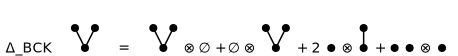

In [21]:
# BCK coproduct uses admissible cuts
kr.display("Δ_BCK", cherry, "=", bck.coproduct(cherry))

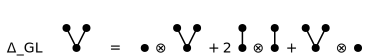

In [22]:
# GL coproduct uses subset-splitting of children
kr.display("Δ_GL", cherry, "=", gl.coproduct(cherry))

## 6. Convolution product of maps

Given scalar-valued maps $f, g$ on trees, the **GL convolution product** is

$$
(f \cdot g)(t) \;=\; \mu_{GL} \circ (f \otimes g) \circ \Delta_{GL}(t).
$$

Since $\Delta_{GL}$ is cocommutative, the convolution product of scalar-valued maps is
commutative (even though $\mu_{GL}$ is noncommutative, scalar multiplication commutes).

The function `gl.map_product(f, g)` computes this, and `gl.map_power(f, n)` computes
the $n$-th convolution power (including negative powers via the convolution inverse).

In [23]:
from math import isclose

f = kr.Map(lambda t: 1 / t.factorial())
f_inv = gl.map_power(f, -1)
fg = gl.map_product(f, f_inv)

### Verify $f \cdot f^{-1} = \varepsilon_{GL}$ for all trees up to order 5

In [24]:
result = True
for t in kr.trees_up_to_order(5):
    if t.list_repr is None:
        continue
    if not isclose(fg(t), gl.counit(t), abs_tol=1e-10):
        result = False
        break
print(result)

True


### Convolution powers

We can also verify that $f^n \cdot f^{-n} = \varepsilon_{GL}$ for $n = 3$.

In [25]:
f3 = gl.map_power(f, 3)
f3_inv = gl.map_power(f, -3)
h = gl.map_product(f3, f3_inv)

result = True
for t in kr.trees_up_to_order(5):
    if t.list_repr is None:
        continue
    if not isclose(h(t), gl.counit(t), abs_tol=1e-10):
        result = False
        break
print(result)

True
